# L4: Diffusion Inference Fundamentals

In this notebook you'll build a diffusion image generation pipeline from scratch — five stages, each as a standalone component — then instrument it to measure where the compute goes. Once you can see the bottleneck, you'll implement a caching strategy that skips redundant transformer calls by exploiting a mathematical property of the denoising process: consecutive steps produce nearly identical noise predictions, so the later ones can be reused for free.

## 📋 Learning Objectives

1. **Build the diffusion pipeline** — Implement the five stages of image generation from scratch: encoding, latent prep, timestep prep, denoising, and decoding
2. **Understand the bottleneck** — See why the denoising transformer dominates compute and what makes it skippable
3. **Implement caching** — Skip redundant transformer calls using temporal locality, the same principle behind SGLang's Cache-DiT
4. **Connect to production** — Map what you built by hand to SGLang-Diffusion's built-in abstractions

<div style="background-color: #fff3e0; padding: 15px; border: 2px solid #f57c00; border-radius: 5px; margin: 20px 0;">

<div style="font-size: 15px; font-weight: bold; color: #e65100; margin-bottom: 8px;">⚠️ This notebook is currently running on CPU. Results will vary, and speed will increase when run on GPU instead.</div>

<p style="margin: 0; font-size: 13px; color: #bf360c;">
This notebook runs a 1.5B parameter model and <b>requires a GPU</b>. It can be run on the DeepLearning.AI platform — attempting to do so will result in extremely slow or failed execution.
</p>

<p style="margin: 10px 0 0 0; font-size: 13px; color: #bf360c;">
To run locally, you will need:
</p>
<ul style="margin: 6px 0 0 0; font-size: 13px; color: #bf360c; padding-left: 20px;">
  <li>A CUDA-compatible GPU</li>
  <li>At least 8GB VRAM</li>
  <li>PyTorch with CUDA support installed</li>
</ul>

</div>

## 1. Diffusion Pipeline

You'll build each of the five stages — Encoding → Latent Prep → Timestep Prep → Denoising → Decoding — run them in sequence, and inspect the output at each step. All stages inherit from a `Stage` base class and communicate through a shared `params` dictionary.

In [1]:
import torch
from diffusers import ZImagePipeline, DiffusionPipeline
from diffusers.image_processor import VaeImageProcessor
from diffusers.pipelines.z_image.pipeline_z_image import (
    calculate_shift,
    retrieve_timesteps,
)
from diffusers.utils.torch_utils import randn_tensor
from tqdm import tqdm
import numpy as np

device = "cpu"

# Shared prompt and image size used throughout the notebook
PROMPT = "A cute anime girl wearing a white hoodie with an orange rust-colored (#D55816) 'SGLang' logo text on the chest, digital illustration, soft lighting"
# IMG_WIDTH = 1024
# IMG_HEIGHT = 1024
IMG_WIDTH = 256
IMG_HEIGHT = 256

class Stage:
    """Base class for all pipeline stages."""

    def __init__(self, pipeline: DiffusionPipeline) -> None:
        self.diffusers_pipeline = pipeline
        self.device = device

    def execute(self, params: dict) -> dict:
        raise NotImplementedError

### Loading the Pretrained Model

We use `ZImagePipeline` — a lightweight diffusion model from Tongyi-MAI. It's small enough to run without excessive wait time while still demonstrating all five stages faithfully. The loaded pipeline object is shared across every stage — no second `from_pretrained` call anywhere in this notebook.

In [2]:
import matplotlib.pyplot as plt

# Load the pretrained diffusion pipeline
model_path = "../models/Tongyi-MAI/Z-Image-Turbo"
pipe = ZImagePipeline.from_pretrained(model_path, low_cpu_mem_usage=True)
pipe.to(device)
print(f"Model loaded: {model_path}")
print(f"Components: {list(pipe.components.keys())}")

Loading pipeline components...:   0%|          | 0/5 [00:00<?, ?it/s]

Loading checkpoint shards:   0%|          | 0/3 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

Model loaded: ../models/Tongyi-MAI/Z-Image-Turbo
Components: ['vae', 'text_encoder', 'tokenizer', 'scheduler', 'transformer']


### Stage 1: Encoding

Text prompt → dense embedding vectors that guide every denoising step. Note the encoder moves to GPU, runs once, then moves back to CPU — the denoising transformer needs that VRAM.

In [3]:
class EncodingStage(Stage):
    """Convert a text prompt into embeddings for the denoising model."""

    def __init__(self, pipeline: DiffusionPipeline) -> None:
        super().__init__(pipeline)
        self.tokenizer = pipeline.tokenizer
        self.text_encoder = pipeline.text_encoder

    def execute(self, params: dict) -> dict:
        self.text_encoder = self.text_encoder.to(self.device)
        prompt = params["prompt"]

        # Wrap prompt in chat template format
        messages = [{"role": "user", "content": prompt}]
        prompt_item = self.tokenizer.apply_chat_template(
            messages,
            tokenize=False,
            add_generation_prompt=True,
            enable_thinking=True,
        )

        # Tokenize with padding to fixed length
        text_inputs = self.tokenizer(
            [prompt_item],
            padding="max_length",
            max_length=512,
            truncation=True,
            return_tensors="pt",
        )

        text_input_ids = text_inputs.input_ids.to(self.device)
        prompt_masks = text_inputs.attention_mask.to(self.device).bool()

        # Extract second-to-last hidden state as prompt embeddings
        # (model-specific  --  other architectures may use last_hidden_state)
        prompt_embeds = self.text_encoder(
            input_ids=text_input_ids,
            attention_mask=prompt_masks,
            output_hidden_states=True,
        ).hidden_states[-2]

        # Keep only non-padded token embeddings
        embeddings_list = [
            prompt_embeds[i][prompt_masks[i]]
            for i in range(len(prompt_embeds))
        ]

        # Free GPU memory  --  encoder not needed until next generation
        del text_input_ids, prompt_masks, text_inputs, prompt_item
        self.text_encoder = self.text_encoder.to("cpu")

        params["prompt_embeds"] = embeddings_list
        return params

Embedding value range (2nd-98th percentile): [-15.1250, 15.5625]


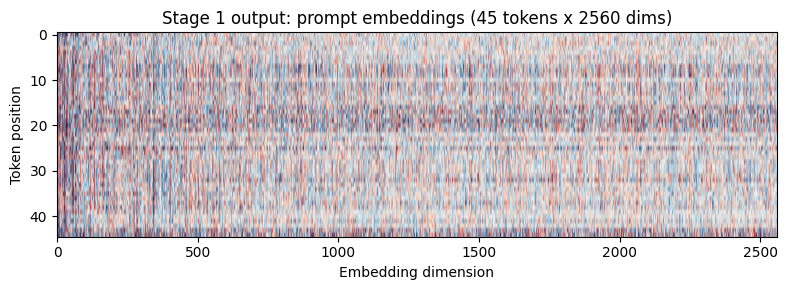

In [4]:
# Run Stage 1 and visualize
encoding_stage = EncodingStage(pipeline=pipe)
params = dict(width=IMG_WIDTH, height=IMG_HEIGHT, prompt=PROMPT)

with torch.inference_mode():
    params = encoding_stage.execute(params)
    torch.cuda.empty_cache()

embeds = params['prompt_embeds'][0]
arr = embeds[:64].cpu().float().numpy()

# Percentile clipping reveals structure  --  values are near zero
# because LayerNorm in the transformer keeps activations centered.
vlo, vhi = np.percentile(arr, [2, 98])
print(f"Embedding value range (2nd-98th percentile): [{vlo:.4f}, {vhi:.4f}]")

fig, ax = plt.subplots(1, 1, figsize=(8, 3))
ax.imshow(arr, aspect='auto', cmap='RdBu_r', vmin=vlo, vmax=vhi)
ax.set_xlabel('Embedding dimension')
ax.set_ylabel('Token position')
ax.set_title(f'Stage 1 output: prompt embeddings ({embeds.shape[0]} tokens x {embeds.shape[1]} dims)')
plt.tight_layout()
plt.show()

### Stages 2-3: Latent and Timestep Preparation

**Latent space:** The VAE compresses 8× per spatial dimension — 1024×1024 becomes 128×128 with 16 channels. 64× fewer positions to denoise.

**Schedule:** 9 steps, fixed seed — same noise means same image, which gives us a fair comparison when we benchmark caching later.

In [5]:
class LatentPreparationStage(Stage):
    """Generate the initial random noise tensor in latent space."""

    def __init__(self, pipeline: DiffusionPipeline) -> None:
        super().__init__(pipeline)
        self.vae_scale_factor = 8

    def execute(self, params: dict) -> dict:
        height, width = params["height"], params["width"]

        # Scale image dimensions to latent space
        height = 2 * (int(height) // (self.vae_scale_factor * 2))
        width = 2 * (int(width) // (self.vae_scale_factor * 2))

        # 16 channels for this model's latent representation
        shape = (1, 16, height, width)
        generator = torch.Generator("cpu").manual_seed(42)
        latents = randn_tensor(
            shape,
            generator=generator,
            device=self.device,
            dtype=torch.float32,
        )

        params["latents"] = latents
        return params


class TimestepPreparationStage(Stage):
    """Compute the denoising schedule (timesteps and step count)."""

    def __init__(self, pipeline: DiffusionPipeline) -> None:
        super().__init__(pipeline)
        self.scheduler = self.diffusers_pipeline.scheduler

    def execute(self, params: dict) -> dict:
        latents = params["latents"]

        # Image sequence length determines the shift factor (mu)
        # for adaptive timestep scheduling
        image_seq_len = (latents.shape[2] // 2) * (latents.shape[3] // 2)
        mu = calculate_shift(
            image_seq_len,
            256,   # base sequence length
            4096,  # max sequence length
            0.5,   # shift min
            1.15,  # shift max
        )

        self.scheduler.sigma_min = 0.0
        # num_inference_steps = 9
        num_inference_steps = 4

        timesteps, num_inference_steps = retrieve_timesteps(
            self.scheduler,
            num_inference_steps,
            self.device,
            sigmas=None,
            mu=mu,
        )

        params["timesteps"] = timesteps
        params["num_inference_steps"] = num_inference_steps
        return params

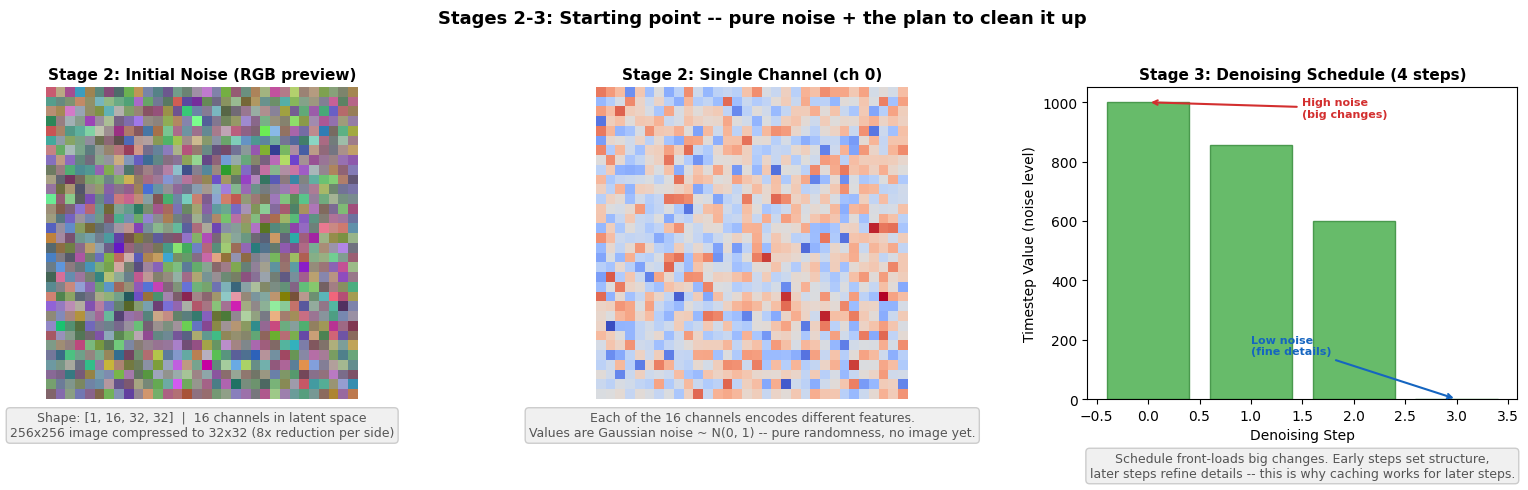

In [6]:
# Run Stages 2-3 and visualize
latent_stage = LatentPreparationStage(pipeline=pipe)
timestep_stage = TimestepPreparationStage(pipeline=pipe)

with torch.inference_mode():
    params = latent_stage.execute(params)
    params = timestep_stage.execute(params)

latents = params['latents']
timesteps = params['timesteps']

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# --- Panel 1: Noise as RGB ---
noise_rgb = latents[0, :3].cpu().permute(1, 2, 0).numpy()
noise_rgb = (noise_rgb - noise_rgb.min()) / (noise_rgb.max() - noise_rgb.min())
axes[0].imshow(noise_rgb)
axes[0].set_title('Stage 2: Initial Noise (RGB preview)', fontsize=11, fontweight='bold')
axes[0].axis('off')
# Annotate shape info
h, w = latents.shape[2], latents.shape[3]
axes[0].text(0.5, -0.12,
    f'Shape: [1, 16, {h}, {w}]  |  16 channels in latent space\n'
    f'{IMG_HEIGHT}x{IMG_WIDTH} image compressed to {h}x{w} (8x reduction per side)',
    transform=axes[0].transAxes, ha='center', fontsize=9, color='#555',
    bbox=dict(boxstyle='round,pad=0.3', facecolor='#f0f0f0', edgecolor='#ccc'))

# --- Panel 2: Single channel heatmap ---
axes[1].imshow(latents[0, 0].cpu().numpy(), cmap='coolwarm')
axes[1].set_title('Stage 2: Single Channel (ch 0)', fontsize=11, fontweight='bold')
axes[1].axis('off')
axes[1].text(0.5, -0.12,
    'Each of the 16 channels encodes different features.\n'
    'Values are Gaussian noise ~ N(0, 1) -- pure randomness, no image yet.',
    transform=axes[1].transAxes, ha='center', fontsize=9, color='#555',
    bbox=dict(boxstyle='round,pad=0.3', facecolor='#f0f0f0', edgecolor='#ccc'))

# --- Panel 3: Timestep schedule ---
ts = timesteps.cpu().numpy()
bars = axes[2].bar(range(len(ts)), ts, color='#4CAF50', alpha=0.85, edgecolor='#388E3C')
axes[2].set_xlabel('Denoising Step', fontsize=10)
axes[2].set_ylabel('Timestep Value (noise level)', fontsize=10)
axes[2].set_title(f'Stage 3: Denoising Schedule ({len(ts)} steps)', fontsize=11, fontweight='bold')

# Annotate first and last bars
axes[2].annotate('High noise\n(big changes)', xy=(0, ts[0]), xytext=(1.5, ts[0]*0.95),
    fontsize=8, color='#D32F2F', fontweight='bold',
    arrowprops=dict(arrowstyle='->', color='#D32F2F', lw=1.5))
axes[2].annotate('Low noise\n(fine details)', xy=(len(ts)-1, ts[-1]), xytext=(len(ts)-3, ts[-1]+ts[0]*0.15),
    fontsize=8, color='#1565C0', fontweight='bold',
    arrowprops=dict(arrowstyle='->', color='#1565C0', lw=1.5))

axes[2].text(0.5, -0.25,
    'Schedule front-loads big changes. Early steps set structure,\n'
    'later steps refine details -- this is why caching works for later steps.',
    transform=axes[2].transAxes, ha='center', fontsize=9, color='#555',
    bbox=dict(boxstyle='round,pad=0.3', facecolor='#f0f0f0', edgecolor='#ccc'))

plt.suptitle('Stages 2-3: Starting point -- pure noise + the plan to clean it up',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.subplots_adjust(bottom=0.24)
plt.show()

### Stage 4: Denoising

80–90% of the compute lives here. 

Each step: the transformer predicts the noise present in the current latent → the scheduler removes it, producing a slightly cleaner image. This repeats for all 9 steps. The transformer call is the expensive line — that's what we'll optimize in Section 2.

In [7]:
class DenoisingStage(Stage):
    """Iteratively denoise latents using the transformer model."""

    def __init__(self, pipeline: DiffusionPipeline) -> None:
        super().__init__(pipeline)
        # self.transformer = pipeline.transformer.to(torch.bfloat16)
        self.transformer = pipeline.transformer.float()
        self.scheduler = pipeline.scheduler
        self.guidance_scale = 5.0

    def execute(self, params: dict) -> dict:
        timesteps = params["timesteps"]
        latents = params["latents"]
        prompt_embeds = params["prompt_embeds"]

        for i, t in enumerate(tqdm(timesteps)):
            # Normalize timestep to [0, 1] range
            timestep = t.expand(latents.shape[0])
            timestep = (1000 - timestep) / 1000

            # Prepare model inputs
            latent_model_input = latents.to(self.transformer.dtype)
            latent_model_input = latent_model_input.unsqueeze(2)
            latent_model_input_list = list(
                latent_model_input.unbind(dim=0)
            )

            # Forward pass through the transformer
            model_out_list = self.transformer(
                latent_model_input_list,
                timestep,
                prompt_embeds,
                return_dict=False,
            )[0]

            # Reconstruct noise prediction from per-sample outputs
            noise_pred = torch.stack(
                [t.float() for t in model_out_list], dim=0
            )
            noise_pred = noise_pred.squeeze(2)
            noise_pred = -noise_pred

            # Scheduler step: x_t -> x_{t-1}
            latents = self.scheduler.step(
                noise_pred.to(torch.float32),
                t,
                latents,
                return_dict=False,
            )[0]

        params["latents"] = latents
        return params

Let's run the denoising stage and decode at **every step** to watch the image emerge from noise. Pay close attention to steps 6–9 — can you see the difference between them? That observation is the foundation for everything in Section 2.

In [ ]:
# Run Stages 4-5: denoise step by step, decoding at each step to visualize
denoising_stage = DenoisingStage(pipeline=pipe)
vae             = pipe.vae
image_processor = VaeImageProcessor(vae_scale_factor=16)

snapshots = []  # (label, PIL image)

with torch.inference_mode():
    ts  = params['timesteps']
    lats = params['latents'].float()
    pe   = params['prompt_embeds']

    # Decode starting noise
    lat_s = (lats / vae.config.scaling_factor) + vae.config.shift_factor
    img   = vae.decode(lat_s.to(vae.dtype), return_dict=False)[0]
    snapshots.append(('Start\n(noise)', image_processor.postprocess(img.float(), output_type='pil')[0]))

    for i, t in enumerate(tqdm(ts, desc="Decode per step")):
        timestep = t.expand(lats.shape[0])
        timestep = (1000 - timestep) / 1000
        lmi      = lats.float().unsqueeze(2)
        lmi_list = list(lmi.unbind(dim=0))

        model_out  = denoising_stage.transformer(lmi_list, timestep, pe, return_dict=False)[0]
        noise_pred = torch.stack([o.float() for o in model_out], dim=0).squeeze(2)
        noise_pred = -noise_pred

        lats = denoising_stage.scheduler.step(noise_pred, t, lats, return_dict=False)[0]

        # Stage 5 (Decoding): decode current latent state to pixels
        lat_s = (lats / vae.config.scaling_factor) + vae.config.shift_factor
        img   = vae.decode(lat_s.to(vae.dtype), return_dict=False)[0]
        snapshots.append((f'Step {i+1}/{len(ts)}',
                          image_processor.postprocess(img.float(), output_type='pil')[0]))

params['latents'] = lats
params['image']   = [snapshots[-1][1]]

# Plot timelapse
n    = len(snapshots)
fig, axes = plt.subplots(1, n, figsize=(2.4 * n, 3.8))

for idx, (ax, (label, img)) in enumerate(zip(axes, snapshots)):
    ax.imshow(img)
    ax.set_title(label, fontsize=9)
    ax.axis('off')
    color = '#999' if idx == 0 else ('#D32F2F' if idx <= max(1, len(ts)//2) else '#1565C0')
    if idx == n - 1:
        color = '#2E7D32'
    for spine in ax.spines.values():
        spine.set_visible(True); spine.set_color(color); spine.set_linewidth(2.5)

plt.suptitle('Stages 4-5: Denoising + Decoding -- noise to pixels',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

Decode per step:   0%|          | 0/4 [00:00<?, ?it/s]

### Stage 5: Decoding

VAE decoder: 16-channel latent → full-resolution RGB pixels. You already saw this output in the timelapse above — this cell wraps it into a reusable pipeline stage.

In [ ]:
class DecodingStage(Stage):
    """Decode denoised latents into a PIL image via the VAE."""

    def __init__(self, pipeline: DiffusionPipeline) -> None:
        super().__init__(pipeline)
        self.vae = pipeline.vae
        self.vae_scale_factor = 8
        self.image_processor = VaeImageProcessor(
            vae_scale_factor=self.vae_scale_factor * 2
        )

    def execute(self, params: dict) -> dict:
        latents = params["latents"]
        latents = latents.to(self.vae.dtype)

        # Reverse the scaling/shifting applied before encoding
        latents = (
            latents / self.vae.config.scaling_factor
        ) + self.vae.config.shift_factor

        # Decode latents -> pixel tensor -> PIL image
        image = self.vae.decode(latents, return_dict=False)[0]
        image = self.image_processor.postprocess(
            image, output_type="pil"
        )

        params["image"] = image
        return params

### Wiring the Stages Together

`Pipeline` chains the five stages using the already-loaded model (no second `from_pretrained`). `Engine` runs them under `torch.inference_mode()`.

In [ ]:
class Pipeline:
    def __init__(self, diffusers_pipeline: DiffusionPipeline):
        self.diffusers_pipeline = diffusers_pipeline
        self.stages = [
            EncodingStage(pipeline=diffusers_pipeline),
            LatentPreparationStage(pipeline=diffusers_pipeline),
            TimestepPreparationStage(pipeline=diffusers_pipeline),
            DenoisingStage(pipeline=diffusers_pipeline),
            DecodingStage(pipeline=diffusers_pipeline),
        ]


class Engine:
    def __init__(self, diffusers_pipeline: DiffusionPipeline):
        self.pipeline = Pipeline(diffusers_pipeline)

    def generate(self, params: dict) -> dict:
        with torch.inference_mode():
            for stage in self.pipeline.stages:
                params = stage.execute(params)
                torch.cuda.empty_cache()
        return params

In [ ]:
# Reuse the already-loaded model  --  no second load
engine = Engine(pipe)

print("Pipeline stages:")
for i, stage in enumerate(engine.pipeline.stages, 1):
    print(f"  {i}. {stage.__class__.__name__}")

output = engine.generate(dict(width=IMG_WIDTH, height=IMG_HEIGHT, prompt=PROMPT))
output['image'][0]

## 2. Cache: Skip Redundant Transformer Calls

Steps 6–9 barely changed in the timelapse. If noise predictions at consecutive steps are nearly identical, why recompute them?

This section builds the caching logic in three parts:
- `CacheStrategy` — the interface: defines `should_skip()` and `reset()`
- `SimpleCacheStrategy` — the implementation: compares consecutive predictions using a relative L2 threshold
- `DenoisingStageWithCache` — the modified denoising loop: skips the transformer call when the cache strategy says to

In [ ]:
class CacheStrategy:
    def should_skip(self, noise: torch.Tensor) -> bool:
        pass
    def reset(self):
        pass



The decision rule compares consecutive noise predictions using a relative L2 norm:

<div style="background-color: #f5f5f5; padding: 12px 20px; border-radius: 5px; margin: 10px 0; text-align: center; font-size: 15px;">
‖current − previous‖ / ‖current‖
</div>

If this value falls below the threshold, the predictions are similar enough that recomputing the next step would add little value — so we skip the transformer call and reuse the cached prediction instead.

In [ ]:
class SimpleCacheStrategy(CacheStrategy):
    def __init__(self, threshold: float = 0.05):
        # if diff consecutive is smaller this threshold, the next step will be skipped
        self.threshold = threshold
        self.last_noise = None
        self.skipped_steps = 0
        self.diff_history = []

    def should_skip(self, noise: torch.Tensor) -> bool:
        if self.last_noise is None:
            self.last_noise = noise
            self.diff_history.append(0.0)
            return False

        diff = torch.norm(noise - self.last_noise) / torch.norm(noise)
        self.diff_history.append(diff.item())
        self.last_noise = noise
        return diff < self.threshold

    def reset(self):
        self.last_noise = None
        self.skipped_steps = 0
        self.diff_history = []

### Denoising with Cache

At each step the loop takes one of two paths:
- **Skip** — reuse the cached noise prediction from the previous step. No transformer call, effectively free.
- **Compute** — run the transformer, update the cache, and check whether the next step can be skipped.

The loop never skips two consecutive steps — at minimum every other step runs the transformer.

In [ ]:
class DenoisingStageWithCache(DenoisingStage):
    def __init__(self, pipeline, cache_strategy: CacheStrategy):
        super().__init__(pipeline)
        self.cache_strategy = cache_strategy

    def execute(self, params: dict) -> dict:
        timesteps = params["timesteps"]
        latents = params["latents"]
        prompt_embeds = params["prompt_embeds"]

        self.cache_strategy.reset()
        skip_next = False
        last_noise = None
        executed_steps = 0

        for i, t in enumerate(tqdm(timesteps)):
            # Preprocessing
            timestep = t.expand(latents.shape[0])
            timestep = (1000 - timestep) / 1000

            latent_model_input = latents.to(self.transformer.dtype)
            prompt_embeds_model_input = prompt_embeds
            timestep_model_input = timestep

            latent_model_input = latent_model_input.unsqueeze(2)
            latent_model_input_list = list(latent_model_input.unbind(dim=0))

            if skip_next:
                # Reuse last noise
                noise_pred = last_noise
                self.cache_strategy.skipped_steps += 1
                skip_next = False
            else:
                # Compute noise
                model_out_list = self.transformer(
                    latent_model_input_list, timestep_model_input, prompt_embeds_model_input, return_dict=False
                )[0]
                noise_pred = torch.stack([t.float() for t in model_out_list], dim=0)
                noise_pred = noise_pred.squeeze(2)
                noise_pred = -noise_pred

                executed_steps += 1

                skip_next = self.cache_strategy.should_skip(noise_pred)
                last_noise = noise_pred

            # Scheduler step
            latents = self.scheduler.step(noise_pred.to(torch.float32), t, latents, return_dict=False)[0]

        params["latents"] = latents
        params["executed_steps"] = executed_steps
        params["diff_history"] = self.cache_strategy.diff_history
        return params


### Benchmark: Cache vs No Cache

Two runs on the same prompt and seed: one with all 9 transformer calls, one with caching enabled. We measure wall-clock time and track which steps were skipped — so you can see exactly where the speedup comes from.

In [ ]:
import time
import pandas as pd
import matplotlib.pyplot as plt


def run_benchmark(
    engine: Engine,
    cache_strategy: CacheStrategy | None = None,
    name: str = "Run",
) -> dict:
    """Run a single generation and collect timing + step metrics."""
    params = dict(width=IMG_WIDTH, height=IMG_HEIGHT, prompt=PROMPT)

    # torch.cuda.synchronize()
    torch.cuda.empty_cache()
    start_time = time.time()
    output = engine.generate(params)
    # torch.cuda.synchronize()
    torch.cuda.empty_cache()
    duration = time.time() - start_time

    if cache_strategy:
        steps = params.get("executed_steps", 9)
        skipped = cache_strategy.skipped_steps
        diff_history = params.get("diff_history", [])
    else:
        steps = params.get("num_inference_steps", 9)
        skipped = 0
        diff_history = []

    return {
        "Name": name,
        "Time (s)": f"{duration:.2f}",
        "Steps Executed": steps,
        "Steps Skipped": skipped,
        "Image": output["image"][0],
        "Diff History": diff_history,
    }

The benchmark swaps the denoising stage in-place rather than rebuilding the entire pipeline — `denoise_idx` finds the stage by type so the rest of the pipeline (encoding, latent prep, timestep prep, decoding) stays untouched.

Two runs on the same prompt and seed:
- **No Cache** — replaces the denoising stage with a plain `DenoisingStage`: all 9 transformer calls, no skipping
- **With Cache** — replaces it with `DenoisingStageWithCache` using a threshold of `0.30`: any step where the relative L2 difference falls below 30% gets skipped

The threshold of `0.30` is the trade-off knob — higher means more steps skipped, lower means closer to the baseline. After both runs, the results are printed as a table and the two generated images are shown side by side with step counts and wall-clock times annotated below each. Same prompt, same seed, same image — the only difference is how many transformer calls were made.

In [ ]:
# Locate the denoising stage in the pipeline
pipeline = engine.pipeline
diffusers_pipeline = pipeline.diffusers_pipeline
denoise_idx = next(
    i for i, s in enumerate(pipeline.stages)
    if isinstance(s, DenoisingStage)
)

# Run without cache
print("Running: No Cache...")
pipeline.stages[denoise_idx] = DenoisingStage(diffusers_pipeline)
res_no_cache = run_benchmark(engine, name="No Cache")

# Run with cache
print("\nRunning: With Cache...")
cache_strat = SimpleCacheStrategy(threshold=0.30)
pipeline.stages[denoise_idx] = DenoisingStageWithCache(
    diffusers_pipeline, cache_strat
)
res_cache = run_benchmark(engine, cache_strat, name="With Cache")

# Compare timing
t_no_cache = float(res_no_cache["Time (s)"])
t_cache = float(res_cache["Time (s)"])
res_no_cache["Speedup"] = "1.00x"
res_cache["Speedup"] = f"{t_no_cache / t_cache:.2f}x"

exclude = {"Image", "Diff History"}
df = pd.DataFrame([
    {k: v for k, v in r.items() if k not in exclude}
    for r in [res_no_cache, res_cache]
])
print("Results:")
print(df.to_markdown(index=False))

# --- Side-by-side image comparison with annotations ---
fig, axes = plt.subplots(1, 2, figsize=(10, 5.5))

axes[0].imshow(res_no_cache["Image"].resize((512, 512)))
axes[0].set_title('No Cache (baseline)', fontsize=12, fontweight='bold', color='#333')
axes[0].axis('off')
axes[0].text(0.5, -0.10,
    f'9/9 transformer calls  |  {res_no_cache["Time (s)"]}s',
    transform=axes[0].transAxes, ha='center', fontsize=10, color='#D32F2F',
    bbox=dict(boxstyle='round,pad=0.3', facecolor='#FFEBEE', edgecolor='#D32F2F'))

axes[1].imshow(res_cache["Image"].resize((512, 512)))
axes[1].set_title('With Cache', fontsize=12, fontweight='bold', color='#333')
axes[1].axis('off')
steps_exec = res_cache["Steps Executed"]
steps_skip = res_cache["Steps Skipped"]
axes[1].text(0.5, -0.10,
    f'{steps_exec}/9 calls ({steps_skip} skipped)  |  {res_cache["Time (s)"]}s  |  {t_no_cache / t_cache:.2f}x faster',
    transform=axes[1].transAxes, ha='center', fontsize=10, color='#1565C0',
    bbox=dict(boxstyle='round,pad=0.3', facecolor='#E3F2FD', edgecolor='#1565C0'))

plt.suptitle('Cache vs No Cache -- same prompt, same seed, same quality',
             fontsize=14, fontweight='bold', y=1.0)
plt.tight_layout()
plt.subplots_adjust(bottom=0.13)
plt.show()


<div style="background-color: #f3e5f5; padding: 15px; border: 2px solid #7b1fa2; border-radius: 5px; margin: 20px 0;">

<div style="font-size: 15px; font-weight: bold; color: #4a148c; margin-bottom: 8px;">📌 Optional reading — everything below this point</div>

<p style="margin: 0; font-size: 13px; color: #4a148c;">
The benchmark results above are the core deliverable for this section. The cells that follow go deeper into <b>temporal locality</b> — the mathematical property that makes caching work. Continue on if you want to learn more about how the cache works! 
</p>

</div>

### Reading the Results: What is Temporal Locality?

**Temporal locality** means that things close together in time tend to be similar. In diffusion, consecutive denoising steps produce nearly identical noise predictions  --  because each step only removes a small amount of noise, the model's "opinion" about what to remove barely changes from one step to the next.

The plot below quantifies this. Each point shows how much the noise prediction changed from the previous step. Look for two patterns:

1. **Early steps (left side):** Large differences  --  the model is rapidly figuring out the global structure (shapes, layout, colors). Every step matters.
2. **Later steps (right side):** Tiny differences  --  the model is making micro-adjustments (sharpening edges, refining textures). These steps are nearly redundant.

When a point falls below the orange threshold line, the next step gets **skipped**  --  we reuse the cached prediction instead of running the transformer. The key insight: we get nearly the same image quality while skipping expensive computation, because temporal locality guarantees those skipped predictions would have been almost identical anyway.

In [ ]:
# --- Temporal locality plot with skip/compute annotations ---
if res_cache["Diff History"]:
    diffs = res_cache["Diff History"]
    fig, ax = plt.subplots(figsize=(10, 5))

    # Color each point by whether it led to a skip or compute
    for i, d in enumerate(diffs):
        if d < cache_strat.threshold and i > 0:
            color, marker, label = '#1565C0', 's', 'Below threshold (next step skipped)'
        else:
            color, marker, label = '#D32F2F', 'o', 'Above threshold (computed)'
        ax.plot(i, d, marker=marker, color=color, markersize=10, zorder=3,
                label=label if i <= 1 else '')

    ax.plot(range(len(diffs)), diffs, color='#888', linewidth=1.5, zorder=2, linestyle='--')

    ax.axhline(y=cache_strat.threshold, color='#FF9800', linewidth=2,
               linestyle='--', label=f'Threshold = {cache_strat.threshold}')

    # Shade regions
    ax.axhspan(0, cache_strat.threshold, alpha=0.08, color='#1565C0')
    ax.axhspan(cache_strat.threshold, max(diffs) * 1.1, alpha=0.08, color='#D32F2F')

    ax.text(len(diffs) - 1, cache_strat.threshold * 0.5,
        'SKIP zone\n(reuse cached prediction)',
        ha='right', fontsize=9, color='#1565C0', fontweight='bold')
    ax.text(len(diffs) - 1, cache_strat.threshold + (max(diffs) - cache_strat.threshold) * 0.4,
        'COMPUTE zone\n(run transformer)',
        ha='right', fontsize=9, color='#D32F2F', fontweight='bold')

    ax.set_xlabel('Denoising Step', fontsize=11)
    ax.set_ylabel('Relative Noise Difference\n||current - previous|| / ||current||', fontsize=10)
    ax.set_title('Temporal Locality: Why caching works for diffusion',
                 fontsize=13, fontweight='bold')
    ax.legend(loc='upper right', fontsize=9)
    ax.grid(True, alpha=0.3)
    ax.set_xlim(-0.5, len(diffs) - 0.5)
    ax.set_ylim(0, max(diffs) * 1.15)
    plt.tight_layout()
    plt.show()

### What Does This Tell Us?

The downward trend in the temporal locality plot is the key takeaway:

- **The curve drops** because the denoising process is converging  --  as the image gets cleaner, there's less and less noise left to remove, so consecutive predictions naturally become more similar.
- **The threshold is the trade-off knob.** Set it too low -> you skip nothing (no speedup). Set it too high -> you skip important structural steps (quality degrades). The sweet spot is skipping only the refinement steps where predictions barely change.
- **This is not an approximation  --  it's exploiting physics.** The mathematical property of the diffusion ODE guarantees that the solution trajectory becomes smoother as it approaches the clean image. We're not guessing which steps to skip; the data tells us.

**The bigger picture:** This same pattern  --  diminishing returns in later iterations  --  appears across many iterative algorithms. In diffusion, it gives us a free speedup. In production, SGLang's built-in **Cache-DiT** uses a more sophisticated version of this strategy, automatically tuned per model.

## 3. Accelerate with Parallelism

Caching skips redundant work. Parallelism throws more hardware at the remaining work. The denoising loop is compute-bound  --  the transformer forward pass dominates each step. With multiple GPUs, you can split it:

| Strategy | What it splits | Best for |
|---|---|---|
| **Tensor Parallelism (TP)** | Model weights  --  each GPU holds a shard of each layer | Large models exceeding single-GPU memory |
| **Sequence Parallelism (SP)** | Image patches  --  each GPU processes a spatial subset | High-resolution images/video with many patches |
| **FSDP** | Weights + optimizer states | Training/fine-tuning; useful to understand for loading checkpoints |

SGLang-Diffusion supports TP and SP out of the box. We won't run them here (single GPU), but the implementation builds directly on the pipeline structure we just built.

## 4. Post-Class Exercises

Everything you built by hand  --  the five stages, the caching, the parallelism  --  is packaged in SGLang-Diffusion. Try the production API below.

| This lesson | SGLang-Diffusion |
|---|---|
| Pipeline & Stages | Encapsulated internally |
| Cache strategy | Built-in Cache-DiT |
| Parallelism (TP/SP) | `num_gpus` argument |

### Install SGLang-Diffusion
```bash
pip install --upgrade pip
pip install uv
uv pip install "sglang[diffusion]" --prerelease=allow
```

### Run With CLI

The CLI provides the quickest way to generate images. You can either launch a persistent server or run a one-off generation.

**Launch a server and send a request:**
```bash
sglang serve --model-path black-forest-labs/FLUX.1-dev --port 3000

curl http://127.0.0.1:3000/v1/images/generations \
  -o >(jq -r '.data[0].b64_json' | base64 --decode > example.png) \
  -H "Content-Type: application/json" \
  -H "Authorization: Bearer $OPENAI_API_KEY" \
  -d '{
    "model": "black-forest-labs/FLUX.1-dev",
    "prompt": "A cute baby sea otter",
    "n": 1,
    "size": "1024x1024",
    "response_format": "b64_json"
  }'
```

**Generate without a server:**
```bash
sglang generate --model-path black-forest-labs/FLUX.1-dev \
  --prompt "A Logo With Bold Large Text: SGL Diffusion" \
  --save-output
```

### Run With Python API

The Python API gives fine-grained control over the generation process. Here's a minimal example that generates a video:
```python
from sglang.multimodal_gen import DiffGenerator


def main():
    # Create a generator from a pre-trained model
    generator = DiffGenerator.from_pretrained(
        model_path="Wan-AI/Wan2.1-T2V-1.3B-Diffusers",
        num_gpus=1,  # Adjust based on your hardware
    )

    # Generate the video
    video = generator.generate(
        sampling_params_kwargs=dict(
            prompt="A curious raccoon peers through a vibrant "
                   "field of yellow sunflowers, its eyes wide "
                   "with interest.",
            return_frames=True,
            output_path="my_videos/",
            save_output=True,
        )
    )


if __name__ == "__main__":
    main()
```